### Imports

In [1]:
import random
import statistics
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm

from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.utils.preprocessing_utils import (
    get_waveform_transformer,
    get_spectrogram_transformer,
)

warnings.filterwarnings('ignore', category=UserWarning)

### Constants

In [2]:
DATASET = DatasetType.SHIPSEAR
FILTERBANK = FilterbankType.MEL

### Profiling the ShipsEar dataset

Number of Files: 2223
Sample Rates: {16000: 2223}
Channels: {1: 2223}

[Durations]
Min: 5.00s
Max: 5.0s
Mean: 5.00s
95th Percentile: 5.00s


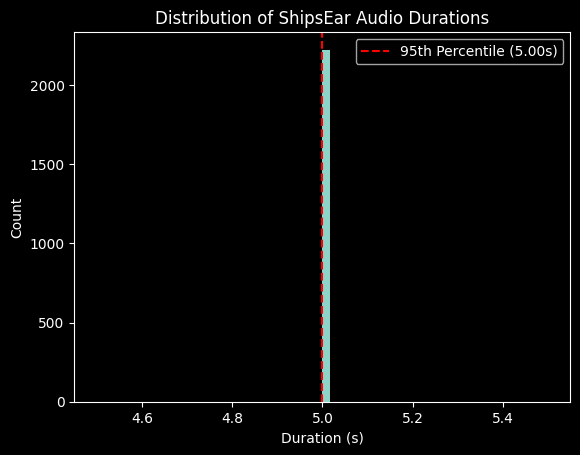

In [3]:
def run_profiling() -> None:
    durations = []
    sample_rates = Counter()
    channels = Counter()

    for file in tqdm(DATASET.input_dir.rglob('*.wav'), desc='Profiling', unit='files', leave=False):
        info = torchaudio.info(file)
        sample_rates[info.sample_rate] += 1
        channels[info.num_channels] += 1
        durations.append(info.num_frames / info.sample_rate)

    print(f'Number of Files: {len(durations)}')
    print(f'Sample Rates: {dict(sample_rates)}')
    print(f'Channels: {dict(channels)}')
    print()
    print('[Durations]')
    print(f'Min: {min(durations):.2f}s')
    print(f'Max: {max(durations):.2}s')
    print(f'Mean: {statistics.mean(durations):.2f}s')
    p95 = np.percentile(durations, 95)
    print(f'95th Percentile: {p95:.2f}s')

    plt.hist(durations, bins=60)
    plt.axvline(p95, color='red', linestyle='dashed', label=f'95th Percentile ({p95:.2f}s)')
    plt.title('Distribution of ShipsEar Audio Durations')
    plt.xlabel('Duration (s)')
    plt.ylabel('Count')
    plt.legend()
    plt.show()


run_profiling()

### Visualising class distribution

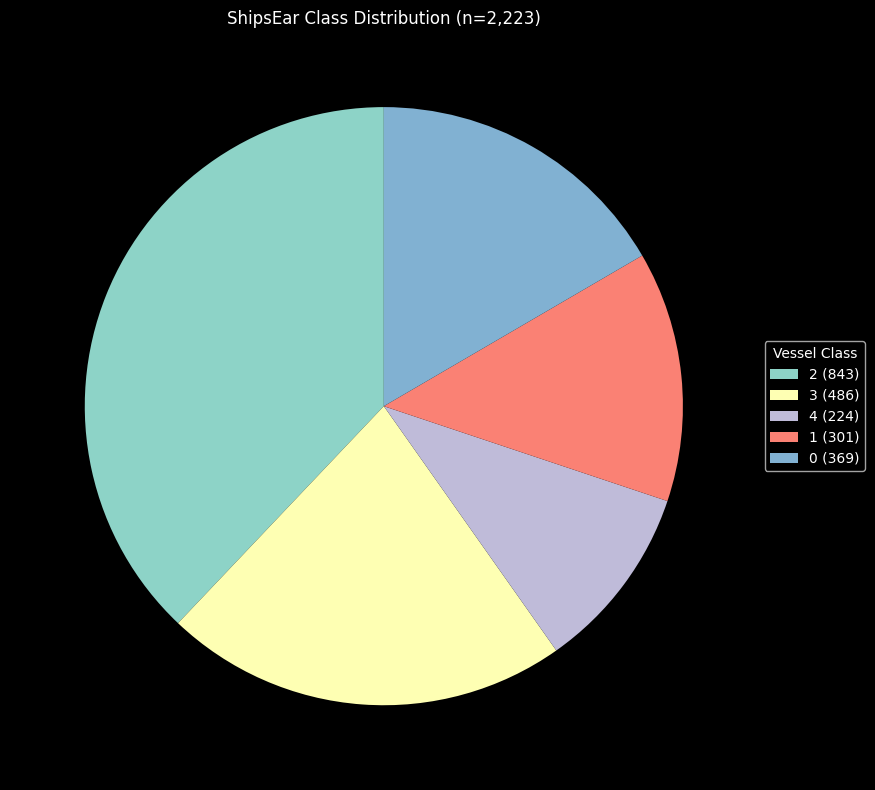

In [4]:
def plot_class_distribution() -> None:
    class_count = Counter()
    for file in tqdm(
        DATASET.input_dir.rglob('*.wav'),
        desc='Finding class distribution',
        unit='files',
        leave=False,
    ):
        label = file.stem.split('_')[0]
        class_count[label] += 1

    labels, counts = zip(*class_count.items())

    fig, ax = plt.subplots(figsize=(10, 8))
    wedges, _ = ax.pie(counts, startangle=90)
    ax.set_title(f'ShipsEar Class Distribution (n={sum(counts):,})')
    legend_labels = [f'{l} ({c:,})' for l, c in zip(labels, counts)]
    ax.legend(
        wedges,
        legend_labels,
        title='Vessel Class',
        loc='center left',
        bbox_to_anchor=(1, 0.5),
    )

    plt.tight_layout()
    plt.show()


plot_class_distribution()

### Visualising ShipsEar audio as Mel Spectrograms

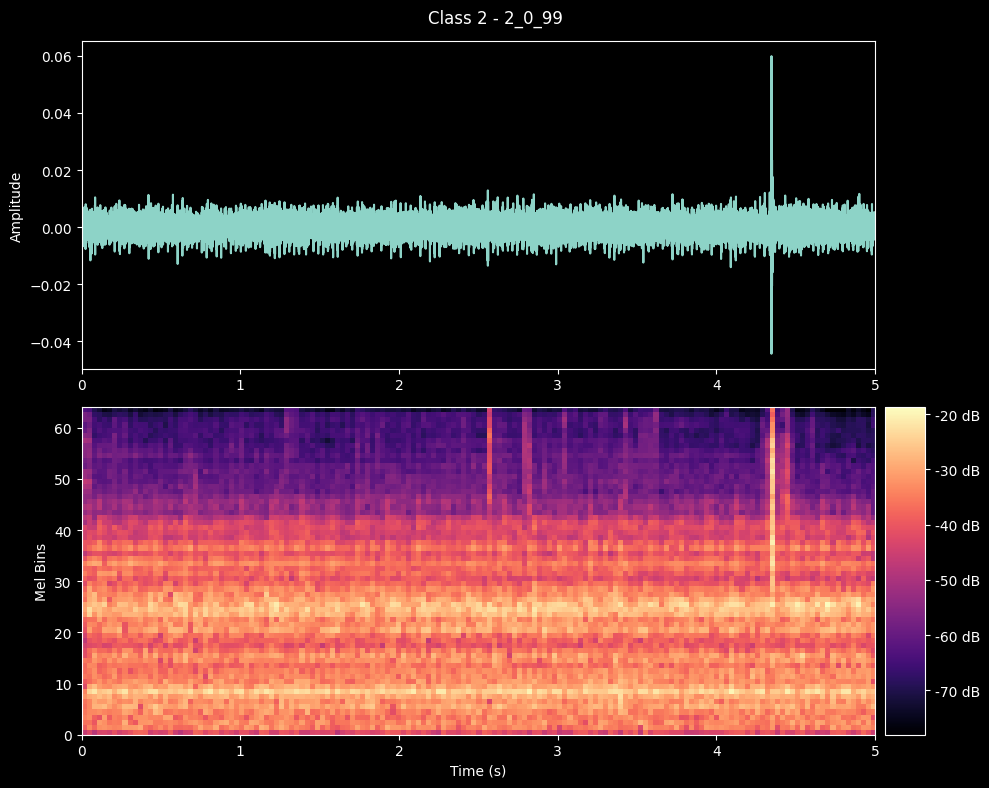

Original: 80000 samples (5.00s)
Preprocessed: 80000 samples (5.00s)


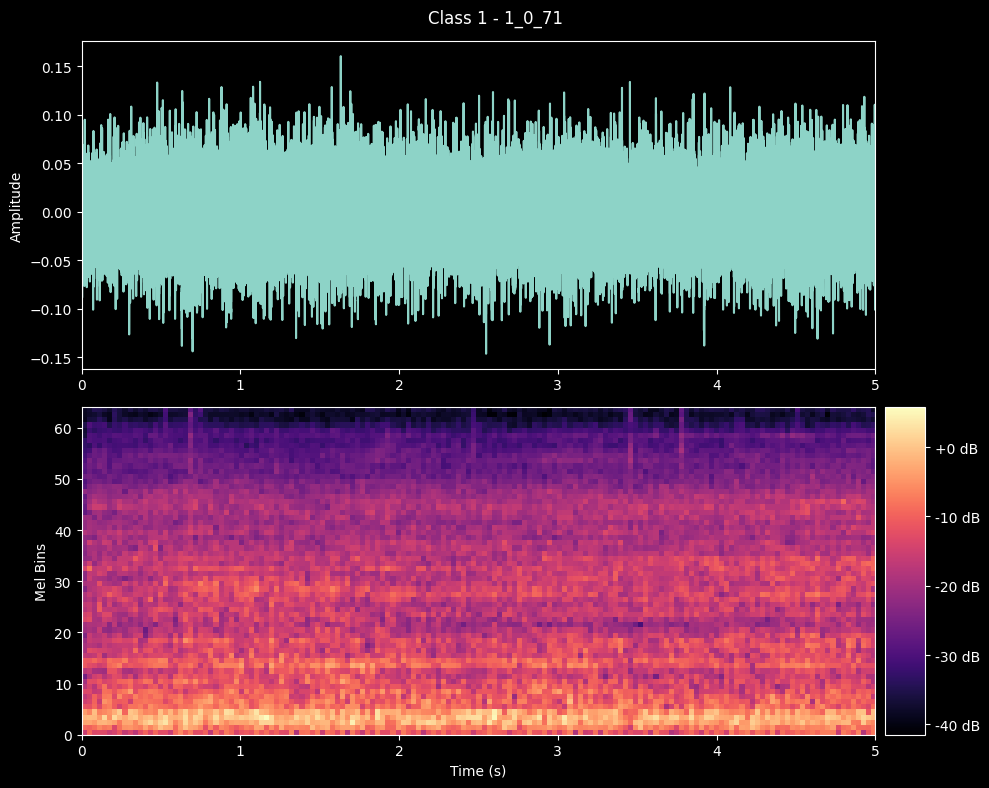

Original: 80000 samples (5.00s)
Preprocessed: 80000 samples (5.00s)


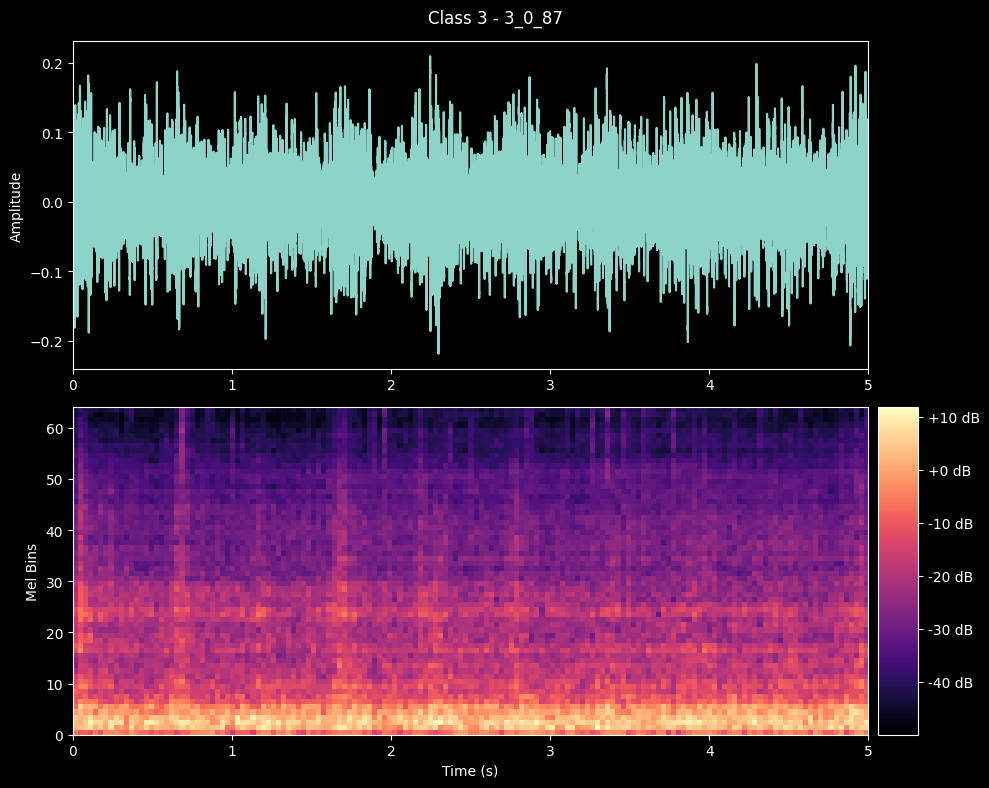

Original: 80000 samples (5.00s)
Preprocessed: 80000 samples (5.00s)


In [5]:
def get_random_audio(dir: Path) -> Path:
    audio_files = list(dir.rglob('*.wav'))
    return random.choice(audio_files)


def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer(DATASET.config)
    spectrogram_transformer = get_spectrogram_transformer(DATASET.config, FILTERBANK)

    for i in range(3):
        audio_path = get_random_audio(DATASET.input_dir)
        label = audio_path.stem.split('_')[0]

        raw_waveform, raw_sample_rate = torchaudio.load(audio_path)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / DATASET.config.target_sample_rate

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        fig.suptitle(f'Class {label} - {audio_path.stem}')

        # Waveform
        time_axis = np.linspace(0, new_duration, new_samples)
        ax1.plot(time_axis, new_waveform[0].numpy())
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes('right', size='5%', pad=0.1)
        cax1.axis('off')

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, DATASET.config.n_bins],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes('right', size='5%', pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

        display(Audio(data=new_waveform, rate=DATASET.config.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1] / raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')


visualise_audio_data()

### Confirming input shape

In [6]:
random_sample = DATASET.get_random_sample(FILTERBANK, encoded=False)
print(random_sample.shape)

torch.Size([1, 64, 157])
